In this notebook, we perform the changeoint analysis proposed by Fiedler, et al., 2018

Reference:
Fiedler, Hainzl, Zöller & Holschneider, Detection of Gutenberg–Richter, "b-Value Changes in Earthquake Time Series", BSSA, 108 (5A), 2778–2787, 2018

In [100]:
from seismostats.analysis import ClassicBValueEstimator, BPositiveBValueEstimator, estimate_mc_maxc
from seismostats.utils import simulate_magnitudes_binned
from functions.determine_changepoint import findCP_bvalues
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path

In [101]:
DIR = Path("data")
variables_df = pd.read_csv(DIR / "variables.csv")
variables = variables_df.to_dict(orient="records")[0]

RESULT_DIR = Path("results/sequence_csv")
DELTA_M = variables["DELTA_M"] 
MC_FIXED = variables["MC_FIXED"]
DMC = variables["DMC"]
CORRECTION_FACTOR = variables["CORRECTION_FACTOR"]
num_seqs = 62

In [102]:
# load sequences
dfs = []

for i in range(1, num_seqs + 1):
    file_path = RESULT_DIR / f"sequence_{i}.csv"
    df = pd.read_csv(file_path)
    dfs.append(df)

/var/folders/2_/2txg_9093x37rv1ls3774xkc0000gn/T/ipykernel_72479/206919439.py:6: DtypeWarning: Columns (11) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)


In [103]:
cleaned_dfs = []

for df in dfs:
    df = df.copy()

    # find main event
    main_rows = df[df["is_main_event"] == True]
    main_time = main_rows.iloc[0].time

    # keep only events BEFORE main event in time
    df_clean = df[
        (df["time"] < main_time) & (~df["is_main_event"])
    ].copy()

    cleaned_dfs.append(df_clean)

sequence 18:

	 1 Change-points found



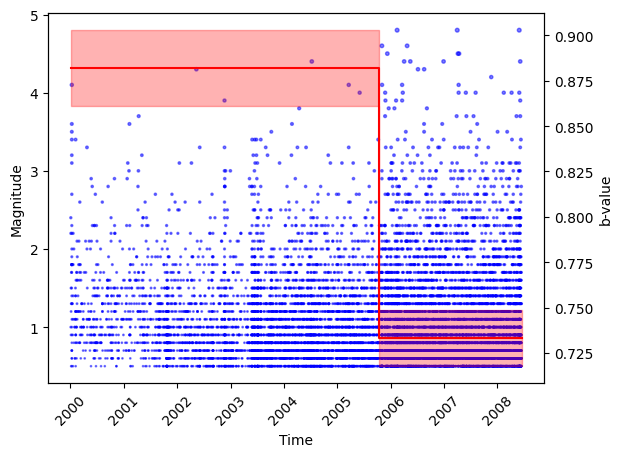

sequence 35:

	 1 Change-points found



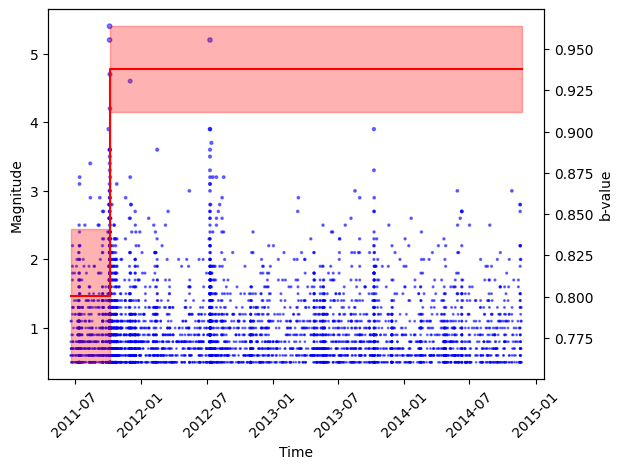

sequence 47:

	 1 Change-points found



/Users/aron/polybox/Projects/b_value_sequences_japan/env/lib/python3.12/site-packages/seismostats/analysis/bvalue/base.py:119: UserWarning: No magnitudes in the lowest magnitude bin are present.Check if mc is chosen correctly.
  warnings.warn(


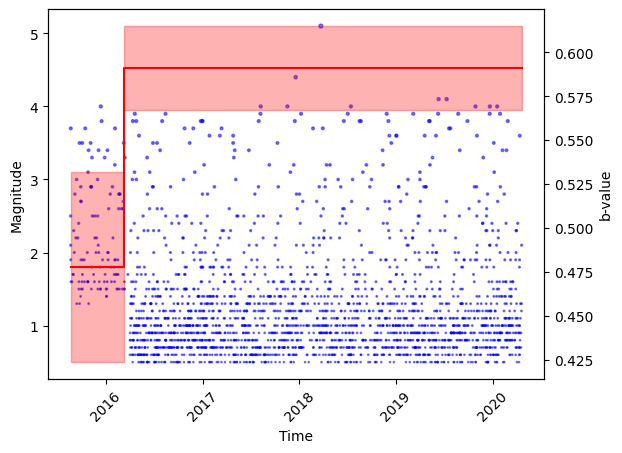

sequence 53:

	 1 Change-points found



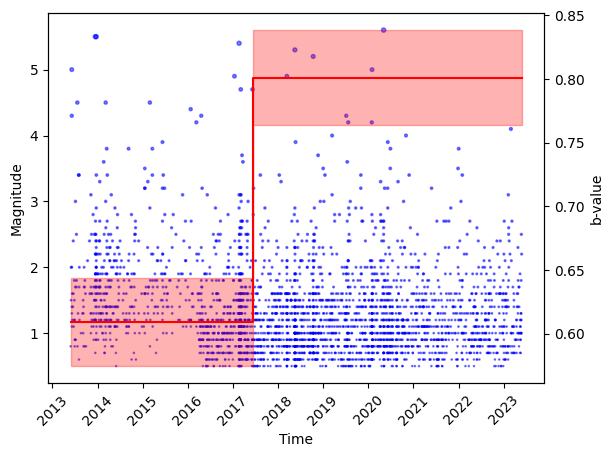

sequence 55:

	 1 Change-points found



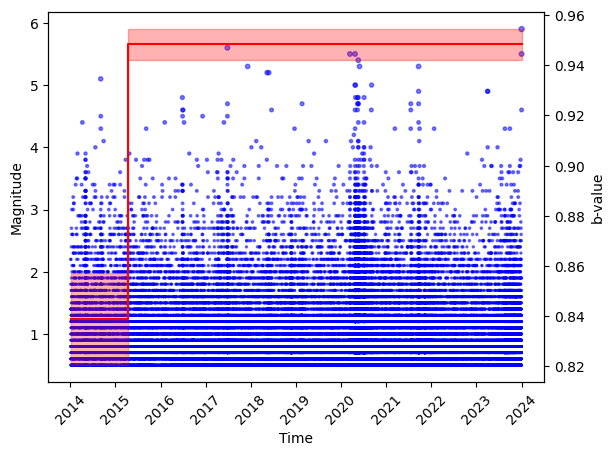

In [132]:
results = []

for ii, df in enumerate(cleaned_dfs):
    m = df["magnitude"].values
    t = pd.to_datetime(df["time"], format='mixed')

    if len(m) < 100:
        continue

    # estimate completeness
    mc, _ = estimate_mc_maxc(m, fmd_bin = 0.1, correction_factor = CORRECTION_FACTOR)

    # only consider positive differences
    estimator = BPositiveBValueEstimator()
    estimator.calculate(m, mc=mc, delta_m=DELTA_M, dmc=DMC)
    m_ind = estimator.idx
    m_pos = m[m_ind]

    # estimate change points:
    chps = [findCP_bvalues(m_pos - mc)]
    if not np.isnan(chps[0]):
        print("sequence %d:" % (ii))
        chps = np.asarray(chps, dtype=int)
        ncs  = len(chps)
        m_best = chps[0]
        estimator.calculate(m[:m_ind[m_best]], mc=mc, delta_m=DELTA_M, dmc=DMC)
        b1 = estimator.b_value
        b1_std = estimator.std
        estimator.calculate(m[m_ind[m_best]:], mc=mc, delta_m=DELTA_M, dmc=DMC)
        b2 = estimator.b_value
        b2_std = estimator.std

        print('\n\t %d Change-points found\n' % (ncs))
        plt.scatter(t, m, c='b', s=np.exp(0.5*(m-mc)), alpha=0.5)
        plt.xlabel('Time')
        plt.ylabel('Magnitude')
        plt.xticks(rotation=45)
        a = plt.twinx()
        a.plot([t.iloc[0], t.iloc[m_ind[m_best]], t.iloc[m_ind[m_best]], t.iloc[-1]], [b1, b1, b2, b2], c='r')
        a.fill_between([t.iloc[0], t.iloc[m_ind[m_best]], t.iloc[m_ind[m_best]], t.iloc[-1]], [b1+b1_std, b1+b1_std, b2+b2_std, b2+b2_std] ,[b1-b1_std, b1-b1_std, b2-b2_std, b2-b2_std], color='r', alpha=0.3)
        a.set_ylabel('b-value')

        # save figure as png, with name "sequence_ii.png" in folder "results/sequence_figures"
        plt.savefig(RESULT_DIR / f"sequence_{ii+1}.png", dpi=300, bbox_inches='tight')
        plt.show()

        results.append({
            "sequence": ii + 1,
            "change_point": chps[0],
            "b1": b1,
            "b1_std": b1_std,
            "b2": b2,
            "b2_std": b2_std
        })
        

## Now, the corresponding synthetic test

sequence 14:

	 1 Change-points found



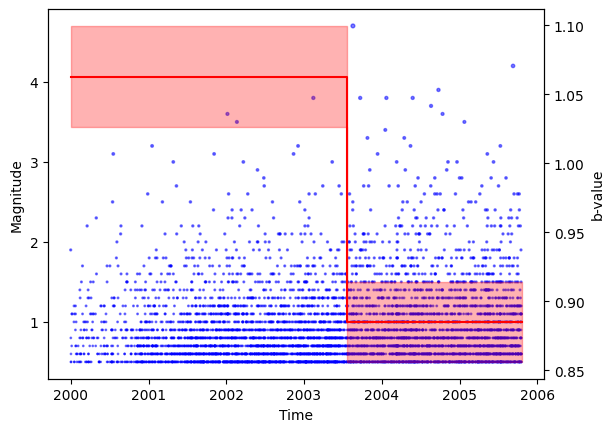

sequence 17:

	 1 Change-points found



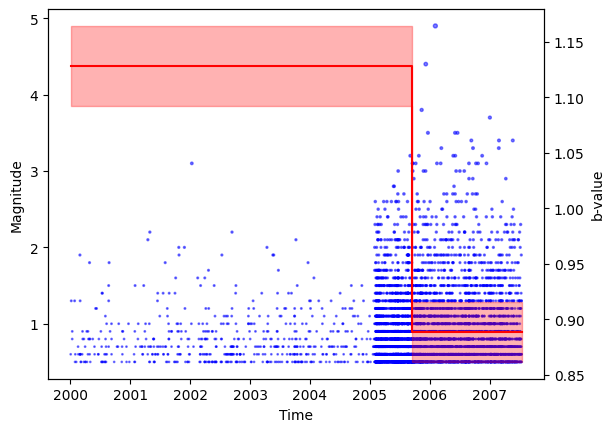

sequence 18:

	 1 Change-points found



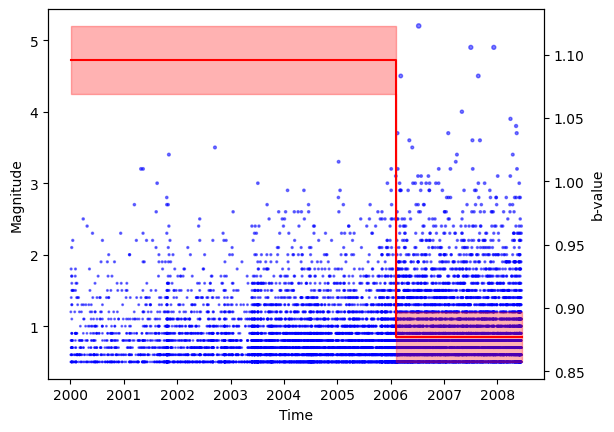

/Users/aron/polybox/Projects/b_value_sequences_japan/env/lib/python3.12/site-packages/seismostats/analysis/bvalue/base.py:104: UserWarning: No magnitudes above the completeness magnitude.
  warnings.warn('No magnitudes above the completeness magnitude.')
/Users/aron/polybox/Projects/b_value_sequences_japan/env/lib/python3.12/site-packages/seismostats/analysis/bvalue/base.py:104: UserWarning: No magnitudes above the completeness magnitude.
  warnings.warn('No magnitudes above the completeness magnitude.')
/Users/aron/polybox/Projects/b_value_sequences_japan/env/lib/python3.12/site-packages/seismostats/analysis/bvalue/base.py:104: UserWarning: No magnitudes above the completeness magnitude.
  warnings.warn('No magnitudes above the completeness magnitude.')


sequence 27:

	 1 Change-points found



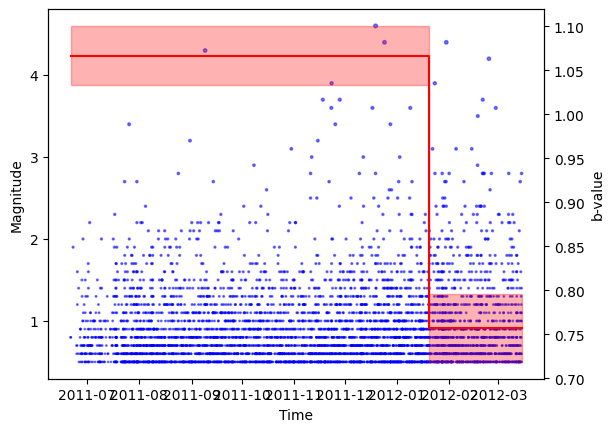

sequence 32:

	 1 Change-points found



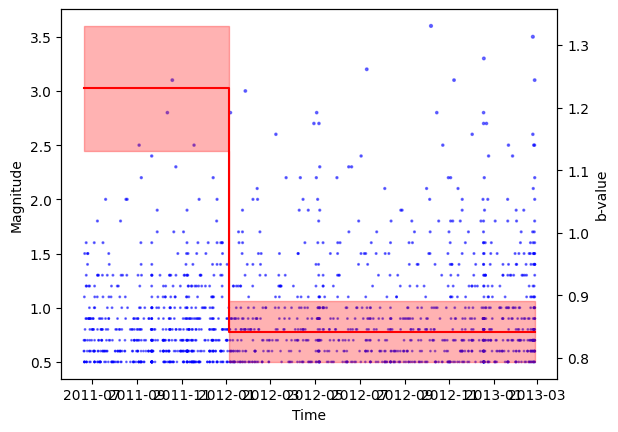

sequence 35:

	 1 Change-points found



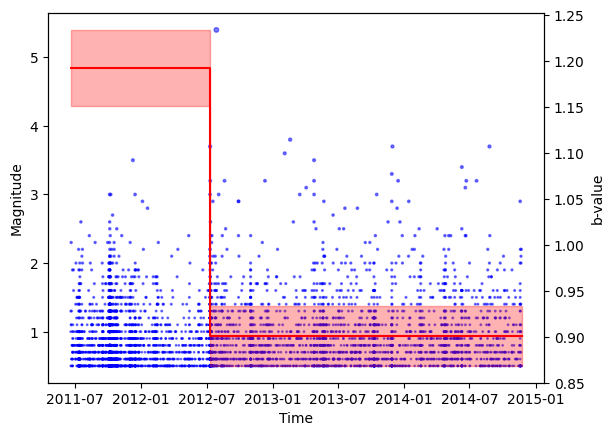

sequence 36:

	 1 Change-points found



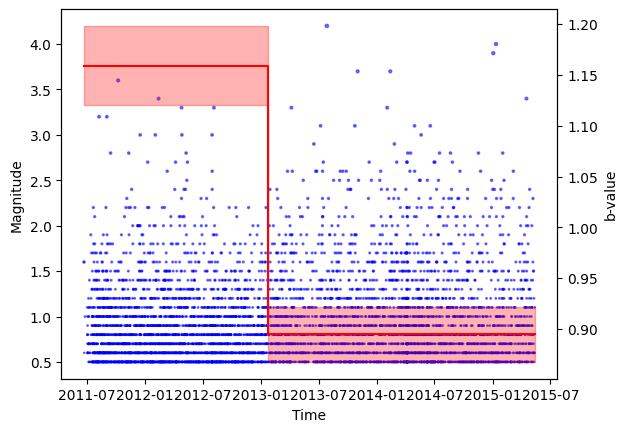

sequence 38:

	 1 Change-points found



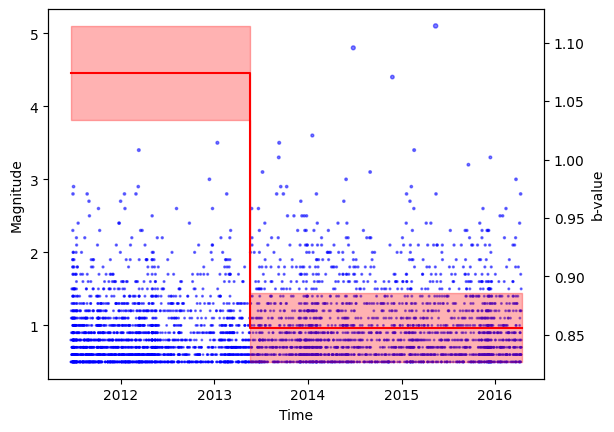

sequence 39:

	 1 Change-points found



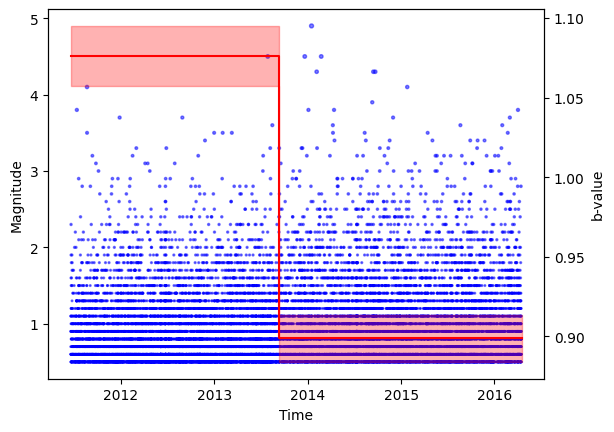

/Users/aron/polybox/Projects/b_value_sequences_japan/env/lib/python3.12/site-packages/seismostats/analysis/bvalue/base.py:104: UserWarning: No magnitudes above the completeness magnitude.
  warnings.warn('No magnitudes above the completeness magnitude.')
/Users/aron/polybox/Projects/b_value_sequences_japan/env/lib/python3.12/site-packages/seismostats/analysis/bvalue/base.py:104: UserWarning: No magnitudes above the completeness magnitude.
  warnings.warn('No magnitudes above the completeness magnitude.')


sequence 51:

	 1 Change-points found



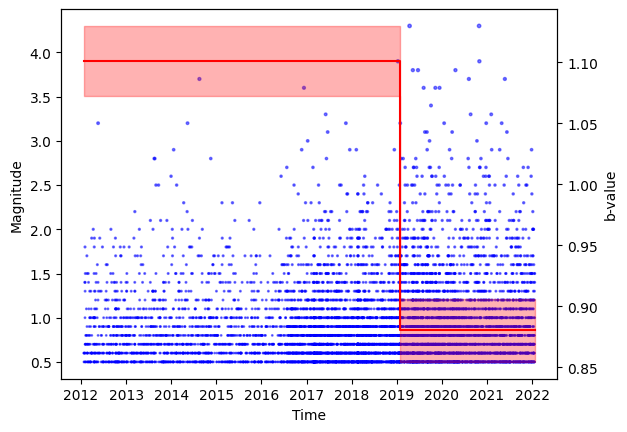

sequence 52:

	 1 Change-points found



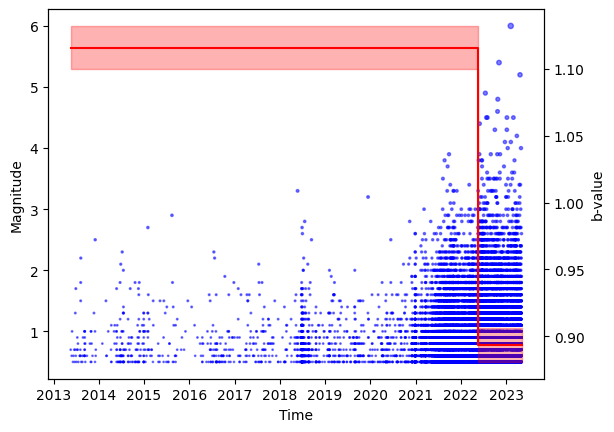

sequence 55:

	 1 Change-points found



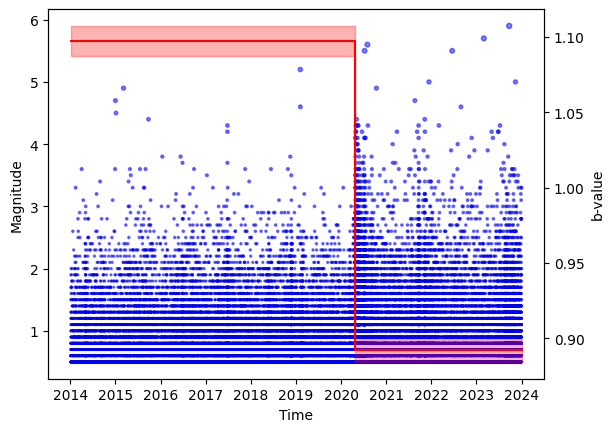

sequence 57:

	 1 Change-points found



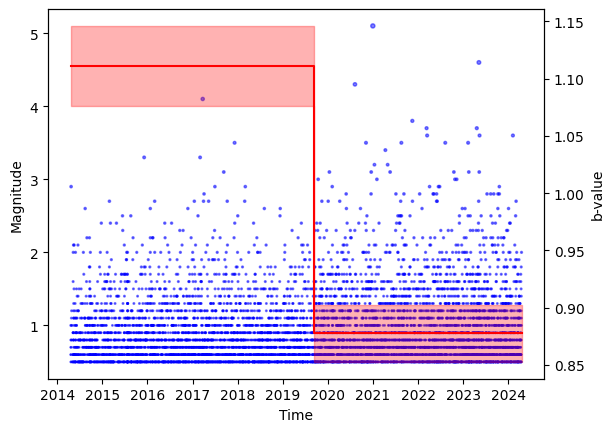

sequence 59:

	 1 Change-points found



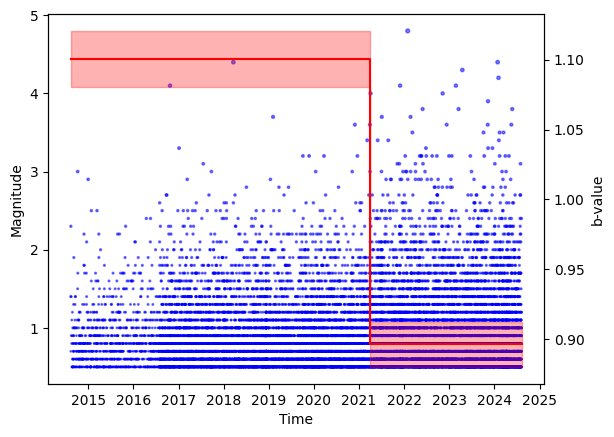

In [133]:
results_H3 = []

for ii, df in enumerate(cleaned_dfs):
    N = len(df)
    b1 = 1.1
    b2 = 0.9

    # synthetics:
    Mmin = 0.0
    T = 1.0
    m1 = simulate_magnitudes_binned(N//2, b=b1, mc = MC_FIXED - 0.2, delta_m=0.1)
    m2 = simulate_magnitudes_binned(N - N//2, b=b2, mc = MC_FIXED - 0.2, delta_m=0.1)
    m = np.concatenate((m1, m2))
    t = pd.to_datetime(df["time"], format='mixed')

    # only consider positive differences
    estimator = BPositiveBValueEstimator()
    estimator.calculate(m, mc=MC_FIXED, delta_m=DELTA_M, dmc=DMC)
    m_ind = estimator.idx
    m_pos = m[m_ind]

    # estimate change points:
    chps = [findCP_bvalues(m_pos - MC_FIXED)]
    if not np.isnan(chps[0]):
        print("sequence %d:" % (ii))
        chps = np.asarray(chps, dtype=int)
        ncs  = len(chps)
        m_best = chps[0]
        estimator.calculate(m[:m_ind[m_best]], mc=MC_FIXED, delta_m=DELTA_M, dmc=DMC)
        b1 = estimator.b_value
        b1_std = estimator.std
        estimator.calculate(m[m_ind[m_best]:], mc=MC_FIXED, delta_m=DELTA_M, dmc=DMC)
        b2 = estimator.b_value
        b2_std = estimator.std

        print('\n\t %d Change-points found\n' % (ncs))
        plt.scatter(t, m, c='b', s=np.exp(0.5*(m-MC_FIXED)), alpha=0.5)
        plt.xlabel('Time')
        plt.ylabel('Magnitude')
        a = plt.twinx()
        a.plot([t.iloc[0], t.iloc[m_ind[m_best]], t.iloc[m_ind[m_best]], t.iloc[-1]], [b1, b1, b2, b2], c='r')
        a.fill_between([t.iloc[0], t.iloc[m_ind[m_best]], t.iloc[m_ind[m_best]], t.iloc[-1]], [b1+b1_std, b1+b1_std, b2+b2_std, b2+b2_std] ,[b1-b1_std, b1-b1_std, b2-b2_std, b2-b2_std], color='r', alpha=0.3)
        a.set_ylabel('b-value')
        plt.show()

        results_H3.append({
            "sequence": ii + 1,
            "change_point": chps[0],
            "b1": b1,
            "b1_std": b1_std,
            "b2": b2,
            "b2_std": b2_std
        })
        

In [134]:
results_H0 = []

for ii, df in enumerate(cleaned_dfs):
    N = len(df)
    b1 = 1.0
    b2 = 1.0

    # synthetics:
    Mmin = 0.0
    T = 1.0
    m1 = simulate_magnitudes_binned(N//2, b=b1, mc = Mmin, delta_m=0.1)
    m2 = simulate_magnitudes_binned(N - N//2, b=b2, mc = Mmin, delta_m=0.1)
    m = np.concatenate((m1, m2))
    t = pd.to_datetime(df["time"], format='mixed')

    # only consider positive differences
    estimator = BPositiveBValueEstimator()
    estimator.calculate(m, mc=MC_FIXED, delta_m=DELTA_M, dmc=DMC)
    m_ind = estimator.idx
    m_pos = m[m_ind]

    # estimate change points:
    chps = [findCP_bvalues(m_pos - MC_FIXED)]
    if not np.isnan(chps[0]):
        print("sequence %d:" % (ii))
        chps = np.asarray(chps, dtype=int)
        ncs  = len(chps)
        m_best = chps[0]
        estimator.calculate(m[:m_ind[m_best]], mc=MC_FIXED, delta_m=DELTA_M, dmc=DMC)
        b1 = estimator.b_value
        b1_std = estimator.std
        estimator.calculate(m[m_ind[m_best]:], mc=MC_FIXED, delta_m=DELTA_M, dmc=DMC)
        b2 = estimator.b_value
        b2_std = estimator.std

        print('\n\t %d Change-points found\n' % (ncs))
        plt.scatter(t, m, c='b', s=np.exp(0.5*(m-MC_FIXED)), alpha=0.5)
        plt.xlabel('Time')
        plt.ylabel('Magnitude')
        a = plt.twinx()
        a.plot([t.iloc[0], t.iloc[m_ind[m_best]], t.iloc[m_ind[m_best]], t.iloc[-1]], [b1, b1, b2, b2], c='r')
        a.fill_between([t.iloc[0], t.iloc[m_ind[m_best]], t.iloc[m_ind[m_best]], t.iloc[-1]], [b1+b1_std, b1+b1_std, b2+b2_std, b2+b2_std] ,[b1-b1_std, b1-b1_std, b2-b2_std, b2-b2_std], color='r', alpha=0.3)
        a.set_ylabel('b-value')
        plt.show()

        results_H0.append({
            "sequence": ii + 1,
            "change_point": chps[0],
            "b1": b1,
            "b1_std": b1_std,
            "b2": b2,
            "b2_std": b2_std
        })
        

/Users/aron/polybox/Projects/b_value_sequences_japan/env/lib/python3.12/site-packages/seismostats/analysis/bvalue/base.py:104: UserWarning: No magnitudes above the completeness magnitude.
  warnings.warn('No magnitudes above the completeness magnitude.')
/Users/aron/polybox/Projects/b_value_sequences_japan/env/lib/python3.12/site-packages/seismostats/analysis/bvalue/base.py:104: UserWarning: No magnitudes above the completeness magnitude.
  warnings.warn('No magnitudes above the completeness magnitude.')
/Users/aron/polybox/Projects/b_value_sequences_japan/env/lib/python3.12/site-packages/seismostats/analysis/bvalue/base.py:104: UserWarning: No magnitudes above the completeness magnitude.
  warnings.warn('No magnitudes above the completeness magnitude.')
/Users/aron/polybox/Projects/b_value_sequences_japan/env/lib/python3.12/site-packages/seismostats/analysis/bvalue/base.py:104: UserWarning: No magnitudes above the completeness magnitude.
  warnings.warn('No magnitudes above the comple

In [135]:
results

[{'sequence': 19,
  'change_point': np.int64(1633),
  'b1': np.float64(0.8818863144310584),
  'b1_std': np.float64(0.020978094110714),
  'b2': np.float64(0.7332622618970139),
  'b2_std': np.float64(0.015603109519664475)},
 {'sequence': 36,
  'change_point': np.int64(400),
  'b1': np.float64(0.8005949605754659),
  'b1_std': np.float64(0.040303720558315465),
  'b2': np.float64(0.9379567237531474),
  'b2_std': np.float64(0.025814285615035966)},
 {'sequence': 48,
  'change_point': np.int64(45),
  'b1': np.float64(0.47772781796000685),
  'b1_std': np.float64(0.05394914538117163),
  'b2': np.float64(0.5912318641418509),
  'b2_std': np.float64(0.023734121217316863)},
 {'sequence': 54,
  'change_point': np.int64(314),
  'b1': np.float64(0.6092418865805427),
  'b1_std': np.float64(0.03467783300584345),
  'b2': np.float64(0.8010684110648423),
  'b2_std': np.float64(0.03723856142792878)},
 {'sequence': 56,
  'change_point': np.int64(2114),
  'b1': np.float64(0.8387526917164521),
  'b1_std': np.fl

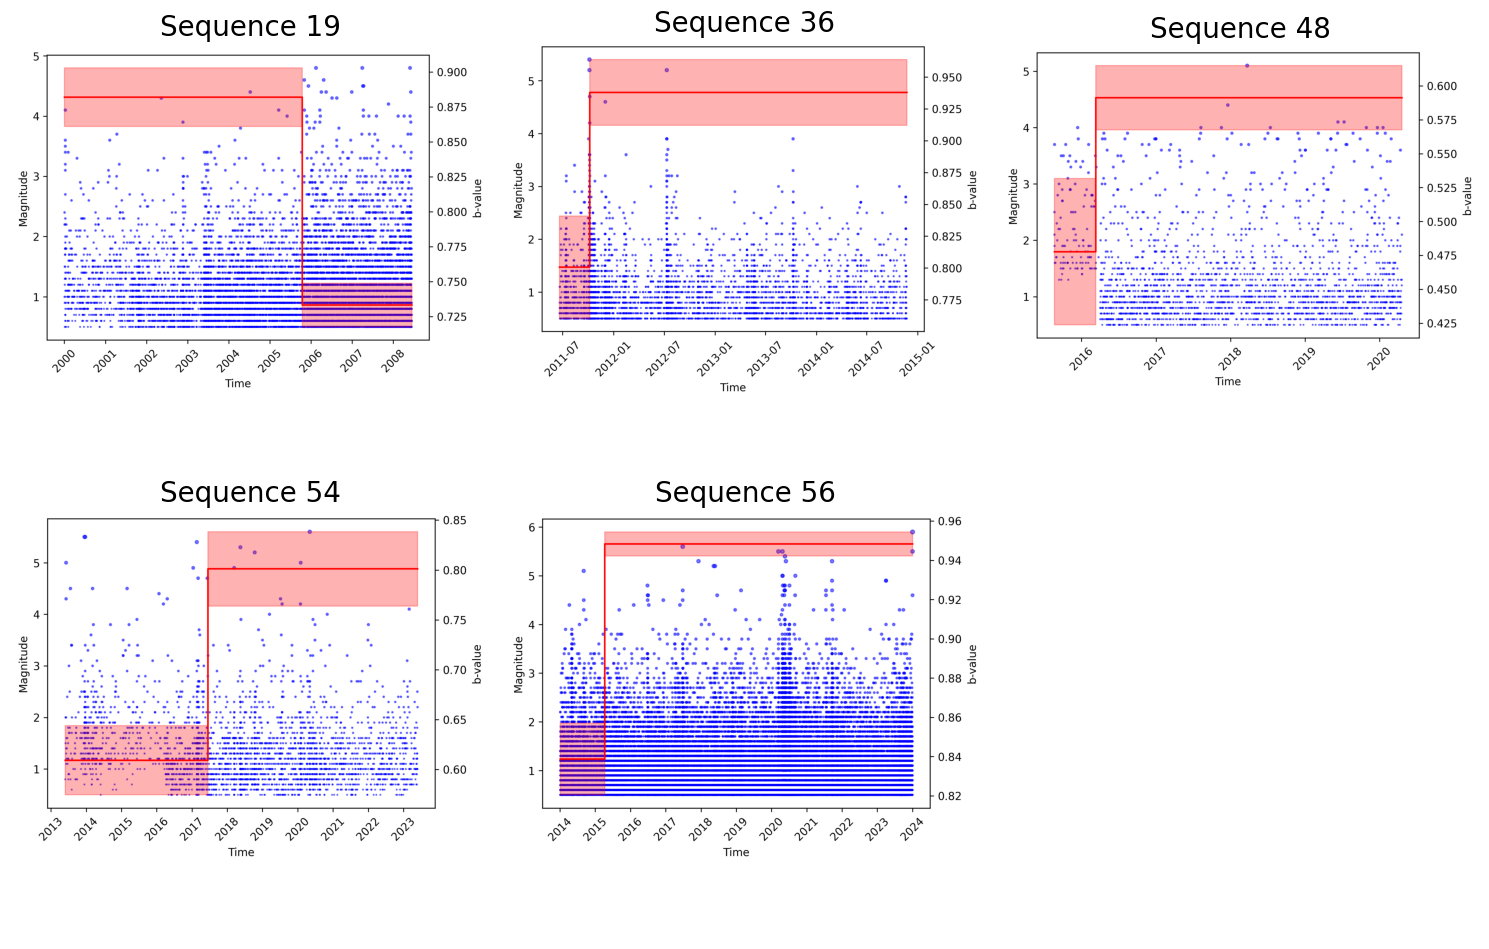

In [163]:
import matplotlib.pyplot as plt
from PIL import Image
import math

# Assuming imgs and seq_nums are already defined
images = [Image.open(image_path) for image_path in imgs]

# Determine grid size (square-ish layout)
n = len(images)
cols = math.ceil(math.sqrt(n))
rows = math.ceil(n / cols)

fig, axes = plt.subplots(rows, cols, figsize=(5*cols, 5*rows))

# Flatten axes for easy iteration (handles 1D/2D cases)
axes = axes.flatten() if n > 1 else [axes]

for i, (img, seq) in enumerate(zip(images, seq_nums)):
    axes[i].imshow(img)
    axes[i].axis("off")
    axes[i].set_title(f"Sequence {seq}", fontsize=20)

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()